In [7]:
import crypy as cp
import numpy as np
from matplotlib import pyplot as plt
from crypy_examples.atom_network import (
    draw_atom,
    draw_atom_simple, 
    draw_bond,
    color_bond,
    color_Se,
    color_Ta,
    r_Se,
    r_Ta,
    r_bond,
    a1,a2,
    p1,p2,p3,p4        
)
from crypy_examples.chiral_interlock import lattice_points_in_hex
from matplotlib.colors import to_rgb

# region Fundamental Parameters
xylim = ((-10,10),(-10,10))

In [8]:
color_Se_HA = [254,164,0]
color_Ta_HA = [0, 176, 240]
color_Se_vesta = [202,137,33]
color_Ta_vesta = [38,115,148]
hexer =  lambda rgb: '#{:02x}{:02x}{:02x}'.format(*rgb)

color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)
color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)
color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)


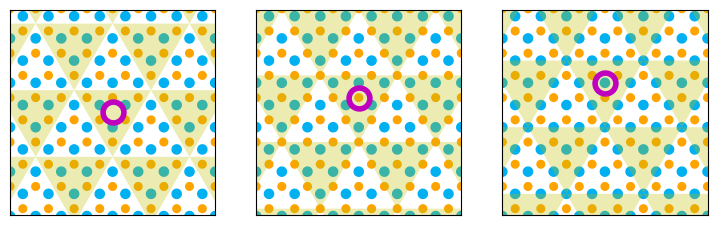

In [30]:
from IPython.core.pylabtools import figsize
# region class setup for figure
# region LEVEL 1: ATOMIC LATTICE
def get_crystal(Num):
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom_simple(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom_simple(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_bond = lambda x,y: draw_bond(x,y,r=r_bond*.6,facecolor=to_rgb(color_bond))

    print("color_bond rgb:",to_rgb(color_bond))
    # bss.add_artist(gen_bond,(p1,p2),label = 'bond1')
    # bss.add_artist(gen_bond,(p1,p3),label = 'bond2')
    # bss.add_artist(gen_bond,(p2,p4),label = 'bond3')
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(3,3)
    bss_sup = cp.Basis2D(pv_sup)
    gen_CDW = lambda xxx,yyy: plt.fill(xxx,yyy,"y",alpha=.3)
    shift = np.array((1/9,2/9))*Num
    cdw_p1 = np.array((2/3,1/3)) +shift
    cdw_p2 = np.array((-1/3,1/3)) +shift
    cdw_p3 = np.array((-1/3,-2/3)) +shift
    cdw_ps = (cdw_p1,cdw_p2,cdw_p3)
    bss_sup.add_artist(gen_CDW,cdw_ps,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    return cry,cry_sup

# region plot
# plt.figure(figsize=(6,6))
fig,axs = plt.subplots(1,3,figsize=(9,3))
for isb in range(3):
    plt.sca(axs[isb])
    cry,cry_sup = get_crystal(isb)
    fig,ax  = cry.plot_crystal()
    cry_sup.plot_crystal()
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])   
    axs[isb].plot(0, isb*np.sqrt(3)/3, 
            marker='o', 
            markersize=15,          # 마커 크기 조절
            markerfacecolor='none', # 내부 채우기 제거 (투명)
            markeredgecolor='m',    # 테두리 색상 (빨강)
            markeredgewidth=4)  
plt.savefig("assets/E08_HCACCC_triangle_v2.svg", bbox_inches='tight')
